## README:

This notebook performs qualitative diagnostics of the learning process by visualizing statistics accumulated during training.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

In [3]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

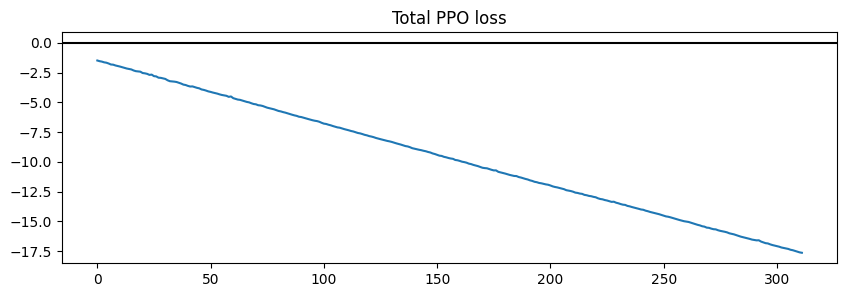

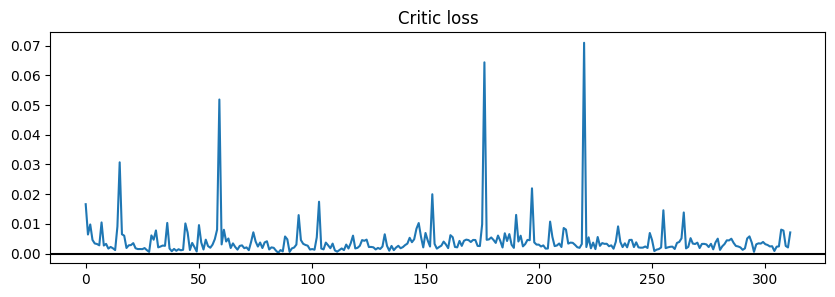

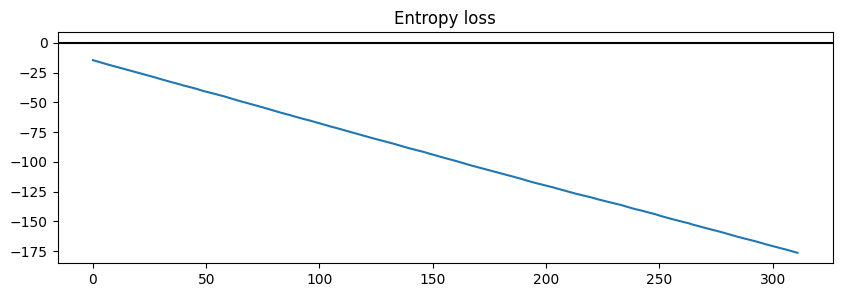

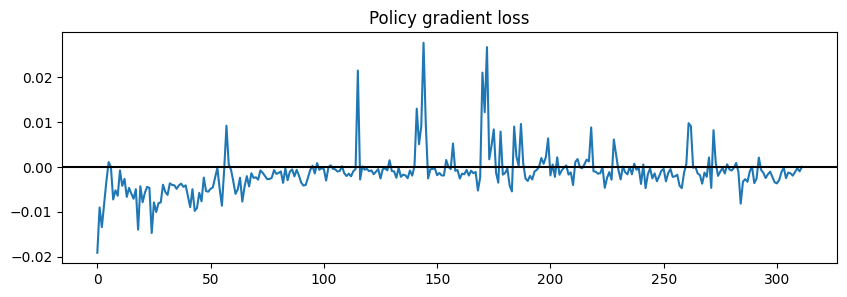

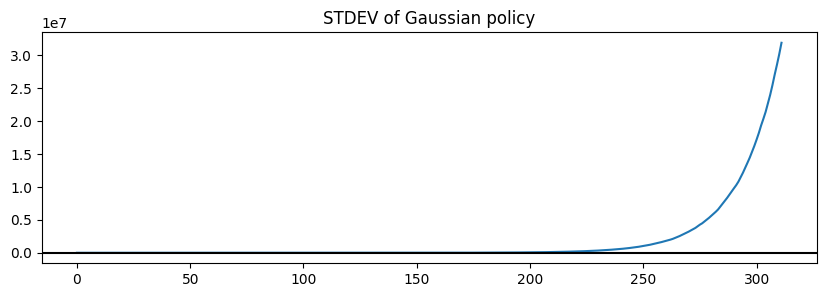

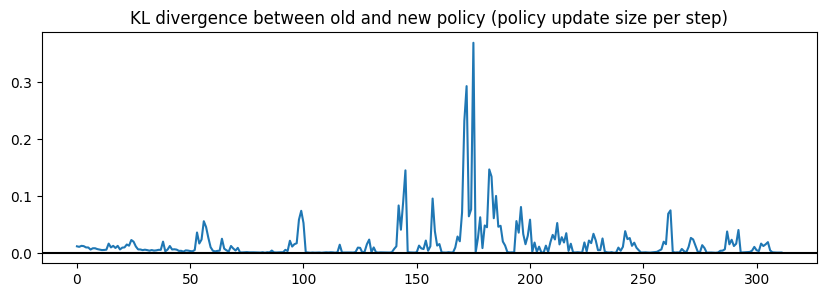

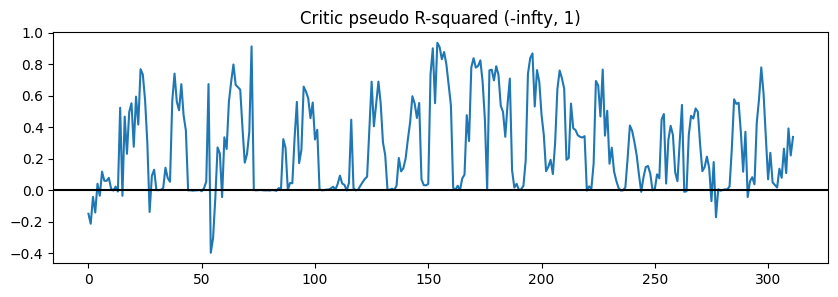

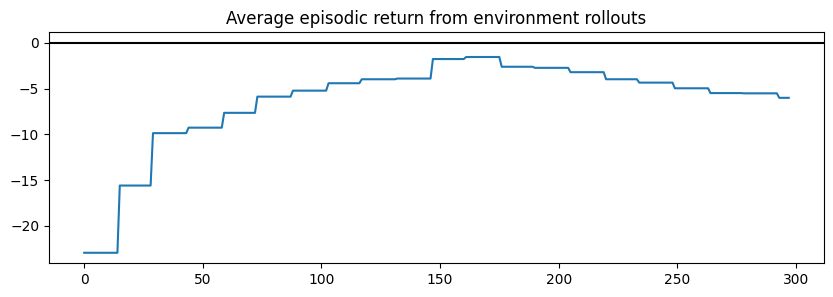

In [16]:
run_name = 'mamba_ppo_20251214_2038_1' # MAMBA with penalized turnover (lambda=0.005)

file_names = [
    ('train__loss.csv', 'Total PPO loss'),
    ('train__value_loss.csv', 'Critic loss'),
    ('train__entropy_loss.csv', 'Entropy loss'),
    ('train__policy_gradient_loss.csv', 'Policy gradient loss'),
    ('train__std.csv', 'STDEV of Gaussian policy'),
    ('train__approx_kl.csv', 'KL divergence between old and new policy (policy update size per step)'),
    ('train__explained_variance.csv', 'Critic pseudo R-squared (-infty, 1)'),
    ('rollout__ep_rew_mean.csv', 'Average episodic return from environment rollouts'),
]

for filename, title in file_names:
    path = os.path.join(DATA_DIR, 'tensorboard_logs', run_name, 'csv_export', filename)
    df = pd.read_csv(path)

    fig, ax = plt.subplots(figsize=(10,3))
    ax.set_title(title)
    ax.plot(df['value'])
    ax.axhline(0, c='black')